In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [26]:

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [27]:
wine=load_wine()
X=wine.data
feature_name=wine.feature_names

In [28]:
print("dataset shape of",X.shape[0])

dataset shape of 178


In [29]:
df=pd.DataFrame(X,columns=wine.feature_names)
print("dataset shape:",df.shape)
print("5 dataset rows:")
df.head()

dataset shape: (178, 13)
5 dataset rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [30]:
selected_features=['alcohol','malic_acid']
X_selected=df[selected_features].values

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_selected)

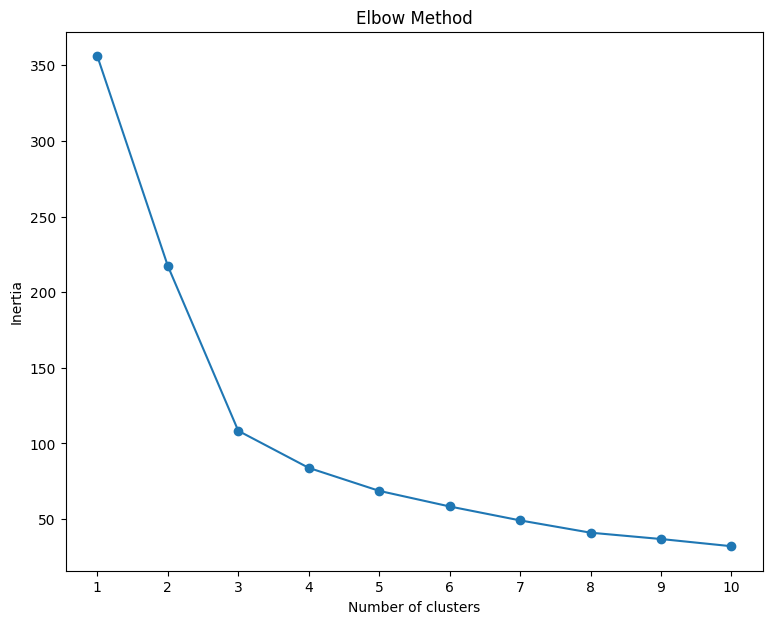

In [32]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9, 7))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_range))
plt.show()